# TP1 best model — Modelos 8 y 6 entrenados con todos los datos

Notebook generado a partir de `TP1 ramiro.ipynb`, conservando su estilo, pero reducido a los dos modelos finalistas del TP:

- **Modelo 6**: ganador del protocolo de comparación de Ramiro (menor MAE medio en validación cruzada).
- **Modelo 8**: ganador de la búsqueda exhaustiva por fuerza bruta sobre 33.343 modelos (modelo ID 16661).

A diferencia del TP original —donde se reservaba un 20 % de los datos para validación—, acá no se separa ninguna fracción: ambos modelos se entrenan con **todos los datos disponibles** (las 675 filas de `X_train.csv` / `y_train.csv`), que es el ajuste final con el que queda cada modelo.

Complementariamente, se agrega una validación cruzada de 5 folds sobre esas mismas 675 filas: cada modelo se entrena con cada fold y se evalúa contra la reserva de 135 filas no vistas, replicando los folds de la búsqueda exhaustiva original.

# Carga de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Armado de los DataFrames:
predictores = pd.read_csv("X_train.csv")
var_ind = pd.read_csv("y_train.csv")["weight"]

print("--- Predictores:")
print(predictores)
print("\n--- Variable independiente:")
print(var_ind)

--- Predictores:
     fage  mage       mature  visits  gained     sex      habit      marital  \
0    34.0    34  younger mom    14.0    28.0    male  nonsmoker      married   
1    36.0    31  younger mom    12.0    41.0  female  nonsmoker      married   
2    37.0    36   mature mom    10.0    28.0  female  nonsmoker      married   
3    32.0    31  younger mom    12.0    48.0  female  nonsmoker      married   
4    32.0    26  younger mom    14.0    45.0  female  nonsmoker      married   
..    ...   ...          ...     ...     ...     ...        ...          ...   
670  36.0    31  younger mom    15.0    28.0    male  nonsmoker  not married   
671  33.0    26  younger mom    13.0    34.0  female  nonsmoker      married   
672  37.0    31  younger mom     8.0    33.0  female  nonsmoker      married   
673  27.0    27  younger mom     7.0    25.0  female  nonsmoker      married   
674  21.0    17  younger mom    12.0    41.0  female  nonsmoker  not married   

      whitemom  
0    

# Construcción del modelo

Primeramente, las variables categóricas se convierten en binarias y se agregan como nuevas series al DataFrame de predictores.

In [2]:
predictores["mature_bin"] = predictores["mature"].map({
    "younger mom": 0,
    "mature mom": 1
})

predictores["sex_bin"] = predictores["sex"].map({
    "female": 0,
    "male": 1
})

predictores["habit_bin"] = predictores["habit"].map({
    "nonsmoker": 0,
    "smoker": 1
})

predictores["marital_bin"] = predictores["marital"].map({
    "not married": 0,
    "married": 1
})

predictores["whitemom_bin"] = predictores["whitemom"].map({
    "not white": 0,
    "white": 1
})

# Modelos

Cada modelo queda englobado en una función `construir_X_modelo_N(df)` que construye su matriz de features a partir del DataFrame de predictores. Ambas se registran en el diccionario `modelos`, desde donde se las llama para el entrenamiento.

- **Modelo 6**: lineal con mage, gained, habit_bin, whitemom_bin, marital_bin, sex_bin (excluyendo pesos extremos: weight < 4 libras).
- **Modelo 8**: lineal con fage, gained, sex_bin, habit_bin, marital_bin y whitemom_bin, más las interacciones sex_bin × marital_bin y marital_bin × whitemom_bin.

In [3]:
def construir_X_modelo_6(df):
    return np.array(df[["mage", "gained", "habit_bin", "whitemom_bin", "marital_bin", "sex_bin"]])

def construir_X_modelo_8(df):
    return np.column_stack([
        df["fage"],
        df["gained"],
        df["sex_bin"],
        df["habit_bin"],
        df["marital_bin"],
        df["whitemom_bin"],
        df["sex_bin"] * df["marital_bin"],
        df["marital_bin"] * df["whitemom_bin"],
    ])

modelos = {
    "Modelo 6": construir_X_modelo_6,
    "Modelo 8": construir_X_modelo_8,
}

# Entrenamiento con todos los datos

Cada modelo se entrena con la totalidad de las 675 filas. En el Modelo 6, los pesos < 4 libras se excluyen únicamente del entrenamiento, como en su definición original.

Al tratarse de métricas medidas sobre los propios datos de entrenamiento, constituyen una estimación optimista del error de predicción: describen el ajuste final con el que queda cada modelo, no reemplazan la validación cruzada del TP original.

In [4]:
resultados_entrenamiento = {}

for nombre, construir_X in modelos.items():
    X_df, y_serie = predictores, var_ind

    if nombre == "Modelo 6":
        mascara = y_serie >= 4
        X_df, y_serie = X_df[mascara], y_serie[mascara]
        print(nombre, "-> casos excluidos (weight < 4 libras):", (~mascara).sum())

    X = construir_X(X_df)
    y = np.array(y_serie)

    reg = LinearRegression()
    reg.fit(X, y)
    y_pred = reg.predict(X)

    resultados_entrenamiento[nombre] = {
        "MAE": mean_absolute_error(y, y_pred),
        "R2": r2_score(y, y_pred),
    }

    print(nombre, "-> MAE:", resultados_entrenamiento[nombre]["MAE"], "| R²:", resultados_entrenamiento[nombre]["R2"])

Modelo 6 -> casos excluidos (weight < 4 libras): 8
Modelo 6 -> MAE: 0.8347945157553203 | R²: 0.08029312640646702
Modelo 8 -> MAE: 0.8769670483220554 | R²: 0.0811238158094626


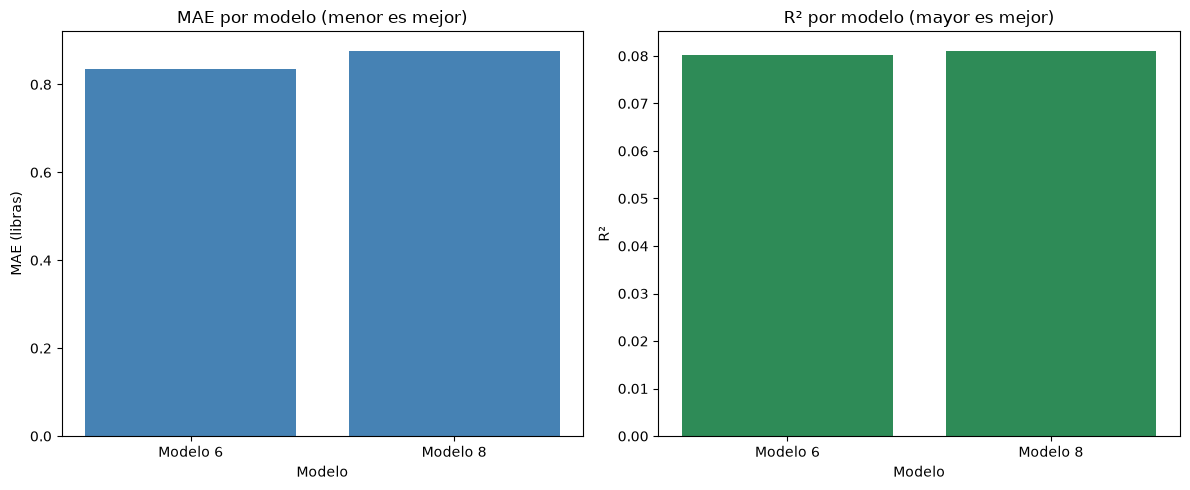

In [5]:
nombres = list(modelos.keys())
MAE = [resultados_entrenamiento[n]["MAE"] for n in nombres]
R2 = [resultados_entrenamiento[n]["R2"] for n in nombres]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(nombres, MAE, color="steelblue")
ax1.set_title("MAE por modelo (menor es mejor)")
ax1.set_xlabel("Modelo")
ax1.set_ylabel("MAE (libras)")

ax2.bar(nombres, R2, color="seagreen")
ax2.set_title("R² por modelo (mayor es mejor)")
ax2.set_xlabel("Modelo")
ax2.set_ylabel("R²")

plt.tight_layout()
plt.show()

## Peso real vs. predicho

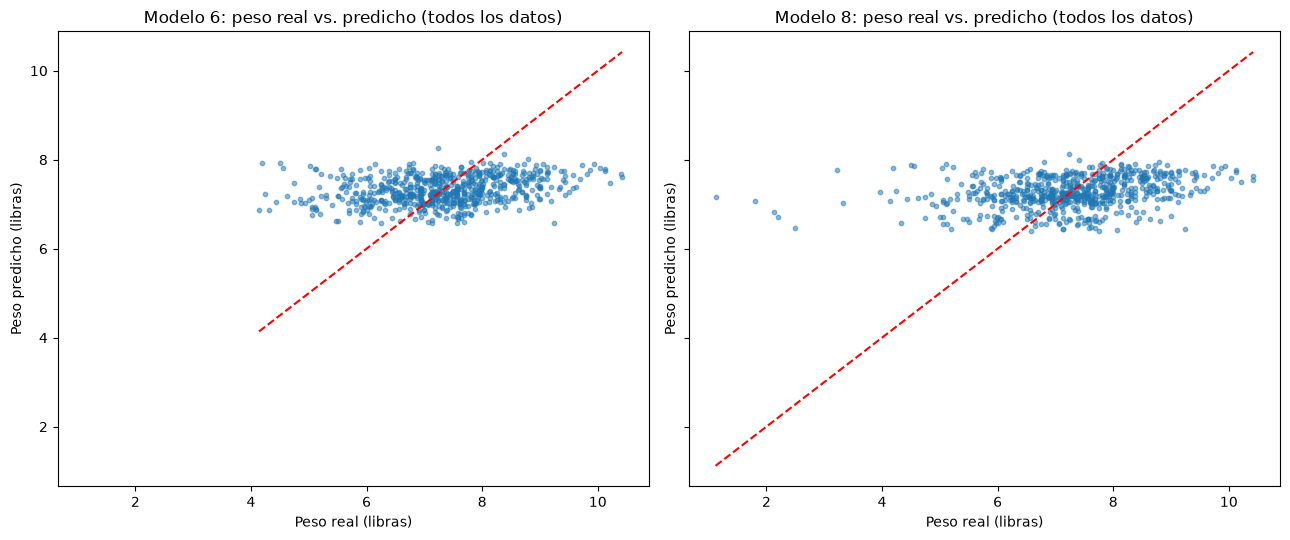

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

for ax, (nombre, construir_X) in zip(ejes, modelos.items()):
    X_df, y_serie = predictores, var_ind

    if nombre == "Modelo 6":
        mascara = y_serie >= 4
        X_df, y_serie = X_df[mascara], y_serie[mascara]

    X = construir_X(X_df)
    y = np.array(y_serie)

    reg = LinearRegression()
    reg.fit(X, y)
    y_pred = reg.predict(X)

    ax.scatter(y, y_pred, s=10, alpha=0.5)

    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, "r--")

    ax.set_xlabel("Peso real (libras)")
    ax.set_ylabel("Peso predicho (libras)")
    ax.set_title(f"{nombre}: peso real vs. predicho (todos los datos)")

plt.tight_layout()
plt.show()

# Validación cruzada (5-fold): entrenar con cada fold y evaluar con la reserva

Las métricas de la sección anterior se miden sobre los propios datos de entrenamiento, por lo que constituyen una estimación optimista del error. Para una estimación más honesta, las 675 filas se dividen en quintos: cada modelo se entrena 5 veces, usando en cada una un 4/5 distinto de los datos (540 filas), y se evalúa contra la reserva de ese fold (las 135 filas que el modelo no vio).

Se usan los mismos folds que la búsqueda exhaustiva original (`KFold` con `shuffle` y semilla 42); el ajuste del Modelo 8 se comprueba contra los valores publicados del modelo ID 16661. En el Modelo 6, los pesos < 4 libras se excluyen solo de la parte de entrenamiento de cada fold; cada reserva se evalúa completa.

In [7]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultados_folds = {}

for nombre, construir_X in modelos.items():
    filas = []
    for fold, (idx_ent, idx_val) in enumerate(kf.split(predictores), start=1):
        X_ent, X_val = predictores.iloc[idx_ent], predictores.iloc[idx_val]
        y_ent, y_val = var_ind.iloc[idx_ent], var_ind.iloc[idx_val]

        if nombre == "Modelo 6":
            mascara = y_ent >= 4
            X_ent, y_ent = X_ent[mascara], y_ent[mascara]

        reg = LinearRegression()
        reg.fit(construir_X(X_ent), np.array(y_ent))
        y_pred = reg.predict(construir_X(X_val))

        filas.append({
            "Fold": fold,
            "N entrenamiento": len(X_ent),
            "N reserva": len(X_val),
            "MAE": mean_absolute_error(np.array(y_val), y_pred),
            "R²": r2_score(np.array(y_val), y_pred),
        })

    resultados_folds[nombre] = pd.DataFrame(filas).set_index("Fold")

tabla_mae = pd.DataFrame({nombre: resultados_folds[nombre]["MAE"] for nombre in modelos})
tabla_mae.index = [f"Fold {i}" for i in tabla_mae.index]

resumen_cv = pd.DataFrame({
    "MAE medio": tabla_mae.mean(),
    "Desvío estándar": tabla_mae.std(),
    "Mínimo": tabla_mae.min(),
    "Máximo": tabla_mae.max(),
    "R² medio": [resultados_folds[nombre]["R²"].mean() for nombre in modelos],
})

# Valores comprobados para estos CSV y estas particiones (fuerza bruta, modelo ID 16661).
np.testing.assert_allclose(tabla_mae["Modelo 8"].mean(), 0.8861021112713019, atol=1e-12, rtol=0)
np.testing.assert_allclose(resultados_folds["Modelo 8"]["R²"].mean(), 0.04613356369807535, atol=1e-12, rtol=0)

for nombre, df_fold in resultados_folds.items():
    print(f"{nombre} — MAE y R² por fold (evaluados contra la reserva):")
    display(df_fold.round(4))

print("Resumen por modelo:")
display(resumen_cv.round(4))
print("R² medio es el promedio de los R² de cada fold; los desvíos no son intervalos de confianza.")

Modelo 6 — MAE y R² por fold (evaluados contra la reserva):


,N entrenamiento,N reserva,MAE,R²
Fold,,,,
1,532,135,0.8465,-0.0031
2,534,135,0.8874,0.0749
3,534,135,0.9054,0.0111
4,535,135,0.9198,0.1098
5,533,135,0.8750,0.0546


Modelo 8 — MAE y R² por fold (evaluados contra la reserva):


,N entrenamiento,N reserva,MAE,R²
Fold,,,,
1,540,135,0.8583,-0.0461
2,540,135,0.8905,0.0641
3,540,135,0.9126,0.0158
4,540,135,0.9195,0.0957
5,540,135,0.8496,0.1011


Resumen por modelo:


,MAE medio,Desvío estándar,Mínimo,Máximo,R² medio
Modelo 6,0.8868,0.0283,0.8465,0.9198,0.0495
Modelo 8,0.8861,0.0314,0.8496,0.9195,0.0461


R² medio es el promedio de los R² de cada fold; los desvíos no son intervalos de confianza.


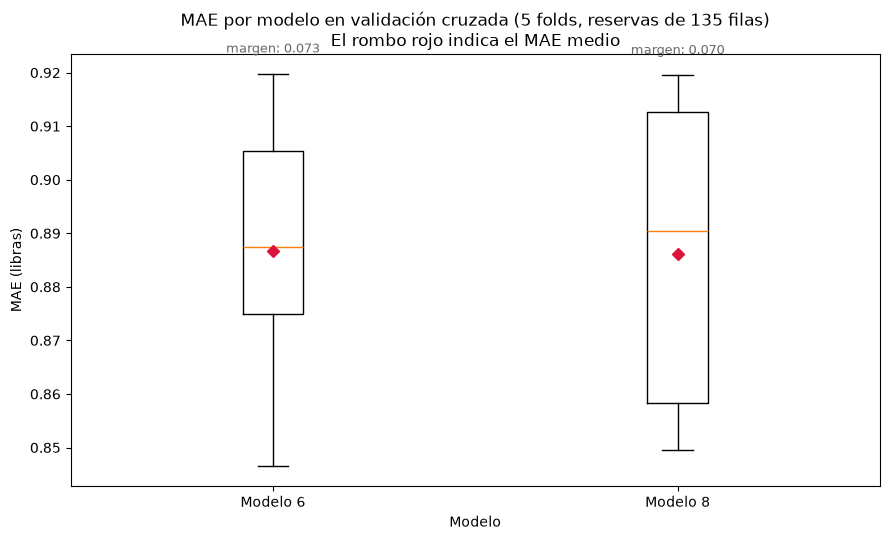

In [8]:
plt.figure(figsize=(9, 5.5))

nombres = list(modelos.keys())
datos_mae = [tabla_mae[nombre].to_numpy() for nombre in nombres]

plt.boxplot(datos_mae, showmeans=True,
            meanprops=dict(marker="D", markerfacecolor="crimson", markeredgecolor="crimson"))
plt.xticks(range(1, len(nombres) + 1), nombres)

for i, mae_fold in enumerate(datos_mae, start=1):
    margen = max(mae_fold) - min(mae_fold)
    plt.text(i, max(mae_fold) + 0.004, f"margen: {margen:.3f}", ha="center", fontsize=9, color="dimgray")

plt.title("MAE por modelo en validación cruzada (5 folds, reservas de 135 filas)\nEl rombo rojo indica el MAE medio")
plt.xlabel("Modelo")
plt.ylabel("MAE (libras)")
plt.tight_layout()
plt.show()

Con todos los datos, el **Modelo 6** alcanza el menor MAE de ajuste (0,835) y el **Modelo 8** el mayor R² (0,081). El R² del Modelo 6, sin embargo, se mide sobre las 667 filas con peso ≥ 4 libras (excluye los 8 casos extremos), por lo que no es directamente comparable con el del Modelo 8, calculado sobre las 675 filas completas.

En la validación cruzada —entrenando con cada fold y evaluando contra la reserva de 135 filas no vistas— los dos modelos quedan prácticamente empatados: el Modelo 8 obtiene el menor MAE medio (0,8861 contra 0,8868) y el Modelo 6 el mayor R² medio (0,049 contra 0,046). Al medirse sobre datos no vistos, esta es la estimación más honesta del error: la diferencia entre ambos (menos de 0,001 libras) está muy por debajo de la variabilidad entre folds (margen de ~0,07 libras), por lo que no hay evidencia de que uno generalice mejor que el otro.